# Results Interpretation

This notebook synthesizes the project in an academic forecasting-paper style.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import CLEAN_SEGMENTS, FIGURES, TABLES, TARGET_COLUMNS, SEGMENT_COLUMNS, SERIES_COLORS, SERIES_LABELS
from src.plotting import annotate_events, save_figure, set_academic_style

set_academic_style()
df = pd.read_csv(CLEAN_SEGMENTS, parse_dates=["date"]).set_index("date").sort_index()
df.index.freq = "MS"

from src.models.evaluation import run_all
validation = pd.read_csv(TABLES / 'data_validation_checks.csv')
metrics = pd.read_csv(TABLES / 'model_metrics.csv') if (TABLES / 'model_metrics.csv').exists() else run_all(df)[0]
best = pd.read_csv(TABLES / 'best_models.csv') if (TABLES / 'best_models.csv').exists() else run_all(df)[1]

## Research Objective

The objective is to forecast Vietnam's monthly international tourist arrivals using VNAT segment data, with attention to seasonality, volatility, and structural breaks.

In [2]:
validation

,check,status,value
0,required_columns,pass,7
1,date_range_start,pass,2012-01-01 00:00:00
2,date_range_end,pass,2025-12-01 00:00:00
3,expected_months,pass,168
4,observed_rows,warn,155
5,duplicated_months,pass,0
6,missing_months,fail,13
7,non_positive_values,pass,0
8,segment_sum_tolerance,warn,29
9,suspicious_repeated_vectors,warn,24


## Data Source and Variables

The dataset is `data/raw/vnat_monthly_segments.csv`, cleaned to `data/processed/vnat_monthly_segments_clean.csv`. Variables include total arrivals and five regional segments: Asia, Europe, Americas, Oceania, and other markets. ASEAN is not used.

## EDA Findings

Observation: arrivals are seasonal, shock-sensitive, and compositionally uneven. Statistical implication: models need seasonal structure and robust post-shock evaluation. Tourism implication: planning should combine aggregate and regional evidence.

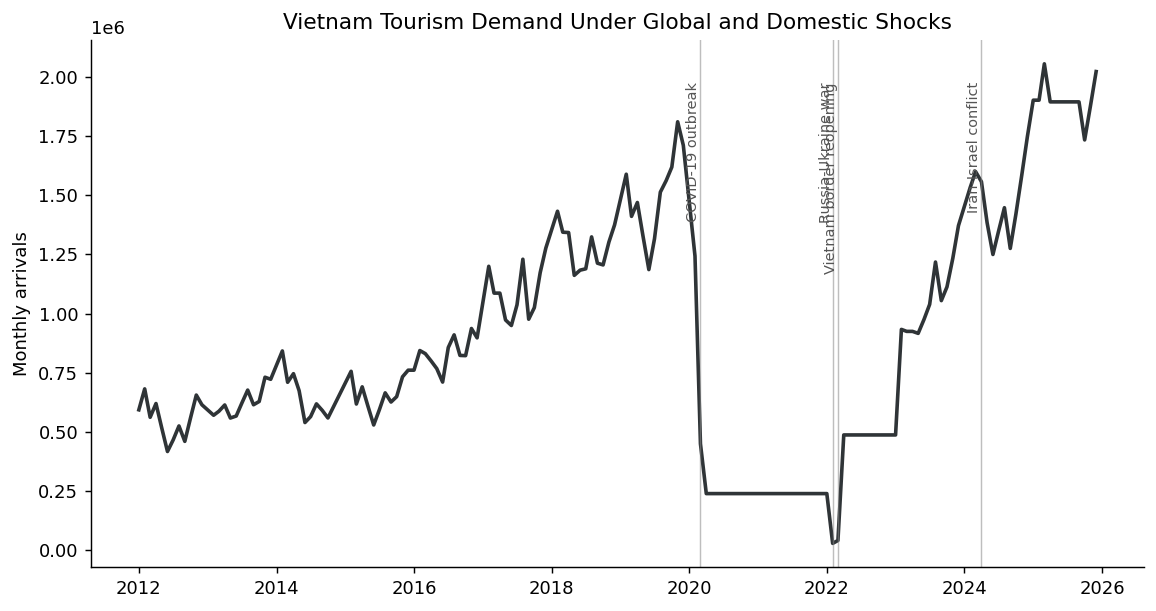

In [3]:
fig, ax = plt.subplots()
ax.plot(df.index, df["international_arrivals"], color=SERIES_COLORS["international_arrivals"])
annotate_events(ax, ["COVID-19 outbreak", "Vietnam border reopening", "Russia-Ukraine war", "Iran-Israel conflict"])
ax.set_title("Vietnam Tourism Demand Under Global and Domestic Shocks")
ax.set_ylabel("Monthly arrivals")
save_figure(fig, FIGURES / "15_final_narrative_series.png")
plt.show()

## Model Performance

Observation: out-of-sample accuracy differs across model classes and segments. Statistical implication: no single specification should be assumed dominant without test-period evidence. Tourism implication: model choice should be revised when recovery dynamics change.

In [4]:
metrics.round(2)

,target,model,status,MAE,RMSE,MAPE,sMAPE
0,international_arrivals,Holt-Winters,ok,1032759.30,1106161.01,67.54,104.52
1,international_arrivals,SARIMA,ok,952091.55,1028593.07,61.78,91.72
2,international_arrivals,SARIMA-GARCH,ok,952091.55,1028593.07,61.78,91.72
3,asia_arrivals,Holt-Winters,ok,838696.47,893738.16,69.55,109.23
4,asia_arrivals,SARIMA,ok,782373.42,839935.60,64.44,97.43
5,asia_arrivals,SARIMA-GARCH,ok,782373.42,839935.60,64.44,97.43
6,europe_arrivals,Holt-Winters,ok,108328.49,124041.73,56.02,80.19
7,europe_arrivals,SARIMA,ok,123662.13,145004.06,62.51,99.58
8,europe_arrivals,SARIMA-GARCH,ok,123662.13,145004.06,62.51,99.58
9,americas_arrivals,Holt-Winters,ok,35617.39,37757.09,41.56,53.20


In [5]:
best[['target', 'model', 'MAE', 'RMSE', 'MAPE', 'sMAPE']].round(2)

,target,model,MAE,RMSE,MAPE,sMAPE
0,americas_arrivals,SARIMA,45721.09,49987.97,56.90,46.58
1,asia_arrivals,SARIMA,782373.42,839935.60,64.44,97.43
2,europe_arrivals,Holt-Winters,108328.49,124041.73,56.02,80.19
3,international_arrivals,SARIMA,952091.55,1028593.07,61.78,91.72
4,oceania_arrivals,Holt-Winters,27949.84,29552.25,64.56,97.48
5,other_markets_arrivals,Holt-Winters,3082.11,3294.42,81.79,143.39


## Forecast Interpretation

Observation: the recovery path remains volatile despite the return of strong arrival volumes. Statistical implication: confidence intervals and residual diagnostics are central outputs. Tourism implication: policymakers and firms should treat forecasts as risk ranges for capacity, promotion, and infrastructure decisions.

## Limitations and Future Improvements

The analysis depends on crawler-derived VNAT data and deterministic imputation for missing or stale observations. Future work should refresh raw VNAT pages, incorporate exogenous indicators such as flight capacity and exchange rates, and test structural-break or regime-switching models.